In [7]:
import pandas as pd
import numpy as np

df=pd.read_csv('..\data\Steel_industry_data.csv')
df.head()

<>:4: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:4: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\owner\AppData\Local\Temp\ipykernel_10760\3215317734.py:4: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df=pd.read_csv('..\data\Steel_industry_data.csv')


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [8]:
zero_rows=df[df['Usage_kWh']==0]

print(len(zero_rows))

print(zero_rows['WeekStatus'].value_counts())
print(zero_rows['Load_Type'].value_counts())

df['date']=pd.to_datetime(df['date'],dayfirst=True)
df=df.set_index('date')
df[df['Usage_kWh']==0]

df=df.sort_index()
df.loc['2018-11-06 23:45':'2018-11-8']

cols=['Usage_kWh','Lagging_Current_Reactive.Power_kVarh','Lagging_Current_Power_Factor','Leading_Current_Power_Factor']
df[cols]=df[cols].replace(0,np.nan).interpolate(method='linear')

df2=df


1
WeekStatus
Weekday    1
Name: count, dtype: int64
Load_Type
Light_Load    1
Name: count, dtype: int64


array([[<Axes: xlabel='date'>, <Axes: xlabel='date'>],
       [<Axes: xlabel='date'>, <Axes: xlabel='date'>],
       [<Axes: xlabel='date'>, <Axes: xlabel='date'>],
       [<Axes: xlabel='date'>, <Axes: xlabel='date'>]], dtype=object)

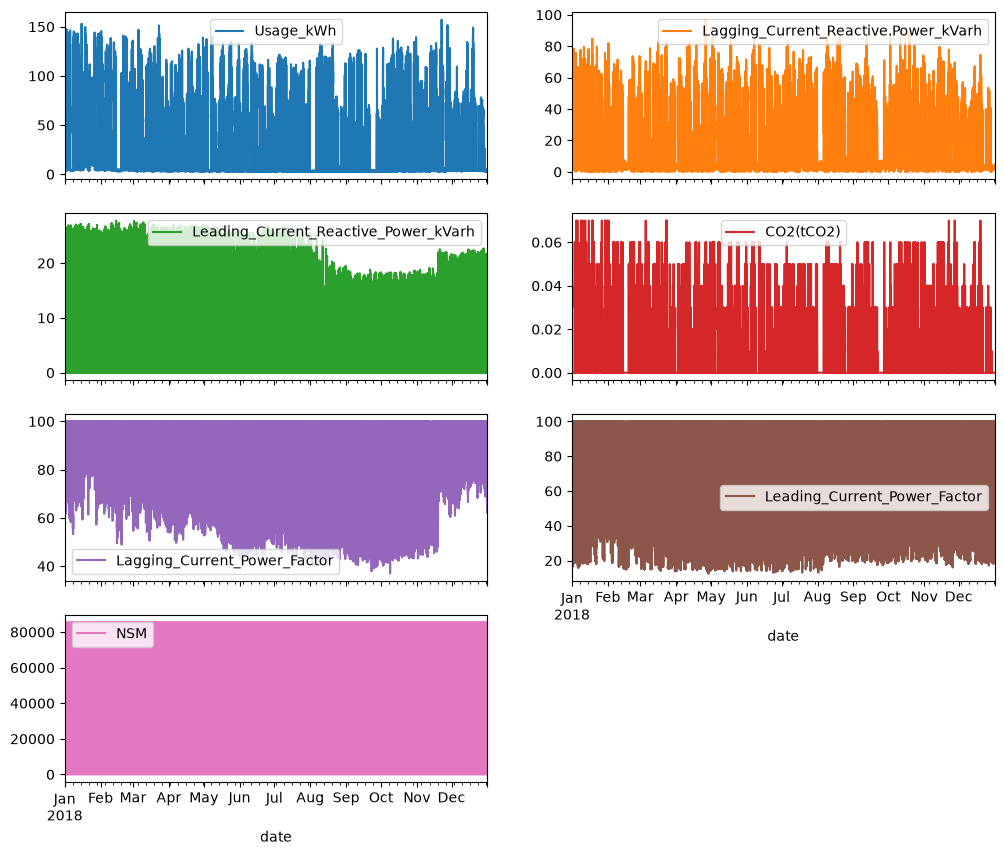

In [9]:
df2.plot(subplots=True,layout=(4,2),figsize=(12,10))

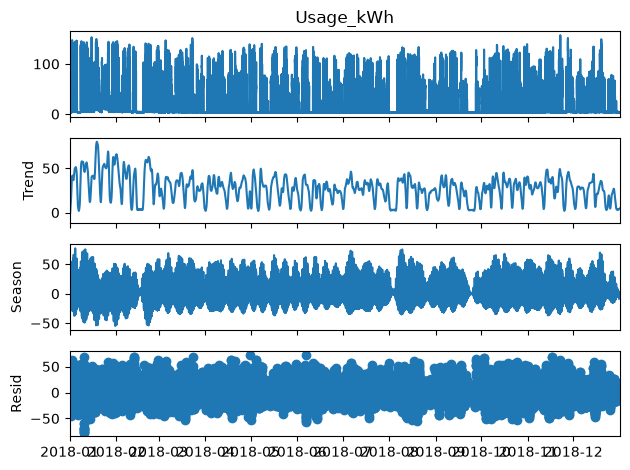

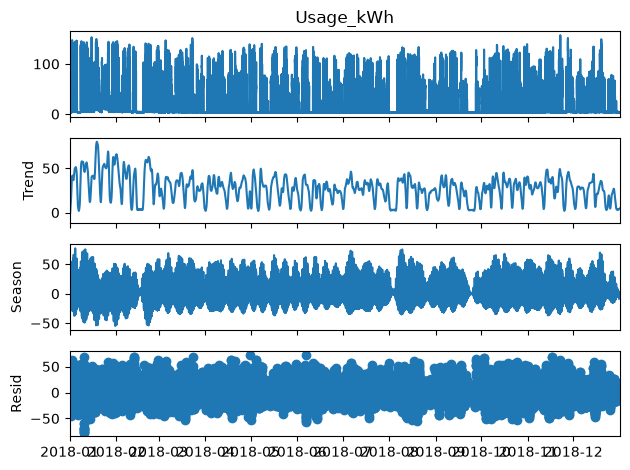

In [10]:
from statsmodels.tsa.seasonal import STL

stl = STL(df2['Usage_kWh'], period=96)
result = stl.fit()
result.plot()

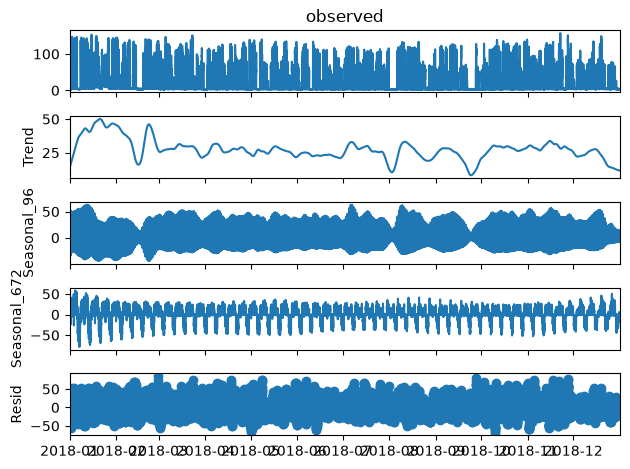

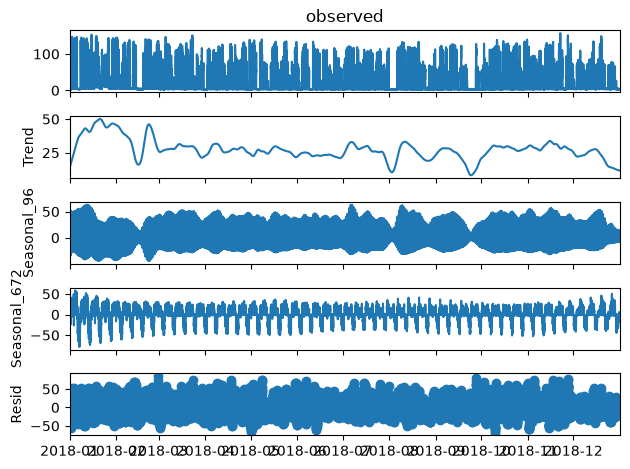

In [11]:
from statsmodels.tsa.seasonal import MSTL

mstl = MSTL(df2['Usage_kWh'], periods=[96, 672])
result = mstl.fit()
result.plot()

In [12]:
print(df2['Usage_kWh'].describe())
print(result.resid.describe())

df2['resid'] = result.resid
df2.groupby('Load_Type')['resid'].describe()

count    35040.000000
mean        27.386993
std         33.444303
min          2.450000
25%          3.200000
50%          4.570000
75%         51.237500
max        157.180000
Name: Usage_kWh, dtype: float64
count    35040.000000
mean         0.030219
std         14.197711
min        -68.185769
25%         -4.338773
50%         -0.066919
75%          2.042563
max         84.829609
Name: resid, dtype: float64


,count,mean,std,min,25%,50%,75%,max
Load_Type,,,,,,,,
Light_Load,18072.0,-1.611051,9.785545,-66.751707,-1.616729,-0.078365,0.596458,73.830487
Maximum_Load,7272.0,2.378043,18.486490,-60.756080,-10.085462,0.261929,12.690645,84.829609
Medium_Load,9696.0,1.328450,16.819242,-68.185769,-6.149831,-0.061883,6.327363,75.390731


C:\Users\owner\AppData\Local\Temp\ipykernel_10760\1734851735.py:26: UserWarning: Glyph 21152 (\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\owner\AppData\Local\Temp\ipykernel_10760\1734851735.py:26: UserWarning: Glyph 27861 (\N{CJK UNIFIED IDEOGRAPH-6CD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\owner\AppData\Local\Temp\ipykernel_10760\1734851735.py:26: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\owner\AppData\Local\Temp\ipykernel_10760\1734851735.py:26: UserWarning: Glyph 25391 (\N{CJK UNIFIED IDEOGRAPH-632F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\owner\AppData\Local\Temp\ipykernel_10760\1734851735.py:26: UserWarning: Glyph 12428 (\N{HIRAGANA LETTER RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\owner\AppData\Local\Temp\ipykernel_10760\1734851735.py:26: UserWarning: Glyph 24133 (\N{CJK UN

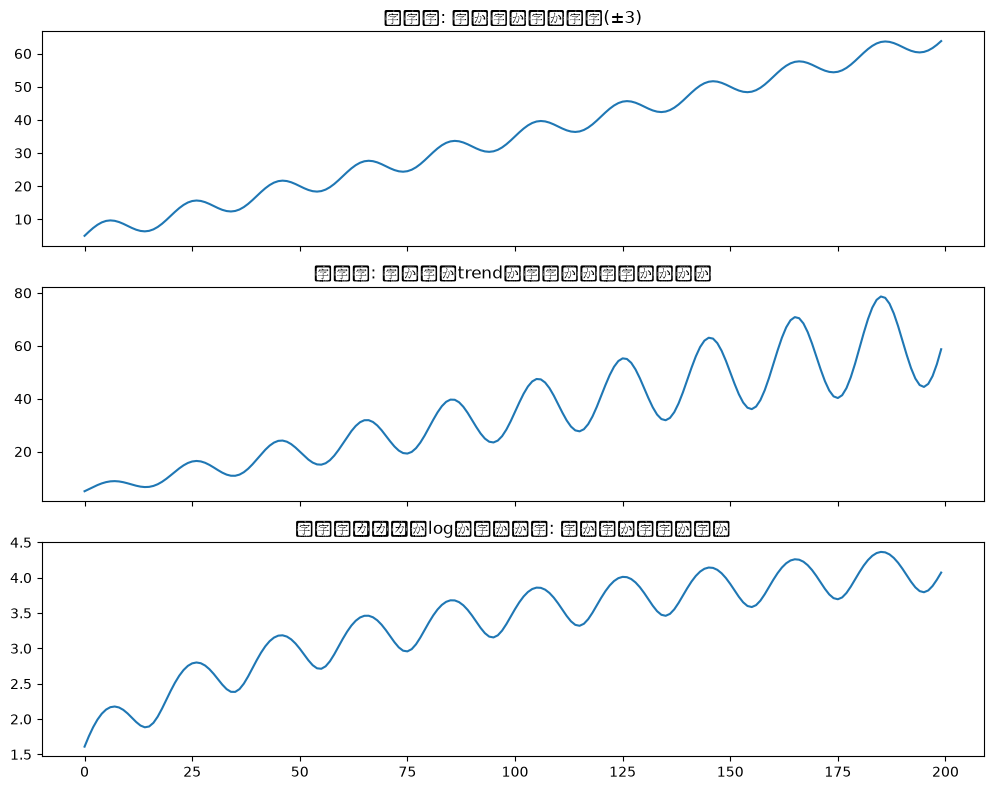

In [13]:
import numpy as np
import matplotlib.pyplot as plt

t = np.arange(200)
trend = 5 + 0.3 * t  # だんだん増えていくトレンド

# 加法的: 季節の振れ幅はtrendに関係なく常に一定(±3)
seasonal_wave = 3 * np.sin(2 * np.pi * t / 20)
y_additive = trend + seasonal_wave

# 乗法的: 季節の振れ幅がtrendに比例して大きくなる(trendの±30%)
seasonal_ratio = 1 + 0.3 * np.sin(2 * np.pi * t / 20)
y_multiplicative = trend * seasonal_ratio

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(t, y_additive)
axes[0].set_title('加法的: 振れ幅が常に一定(±3)')

axes[1].plot(t, y_multiplicative)
axes[1].set_title('乗法的: 振れ幅がtrendに比例して拡大していく')

axes[2].plot(t, np.log(y_multiplicative))
axes[2].set_title('乗法的データをlogに通した後: 振れ幅が一定に戻る')

plt.tight_layout()
plt.show()